In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

In [2]:
from myproject import GalaxyGroup, Subhalo, ListGalaxyGroup, AstroPlotter
import h5py as h5
import numpy as np

In [3]:
sim = 'TNG300-1'
scratchDataDirc = f'/scratch/poulin.al/lopsided/{sim}/data'
scratchPlotDirc = f'/scratch/poulin.al/lopsided/{sim}/plots'
localDataDirc = f'/Users/alexpoulin/Library/CloudStorage/OneDrive-NortheasternUniversity/TGB–Data'


In [4]:
generalRewrite = False

## load data from hdf5 file


In [5]:
data_file = scratchDataDirc + f'/galaxy_data_{sim}.hdf5'
# data_file = localDataDirc + f'/galaxy_data_{sim}.hdf5'
with h5.File(data_file, 'r') as f:
    list_of_galaxy_groups = ListGalaxyGroup.from_hdf5(f)
print(f'Loaded galaxy data from {data_file}')

Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/data/galaxy_data_TNG300-1.hdf5


In [6]:
#filter to groups with stellar mass > 10^{14} Msun
filtered_galaxy_groups = list_of_galaxy_groups.filterSubhalos(minGGMass=1e14)
# print(f"len filtered: {len(filtered_galaxy_groups)}")
filtered_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_galaxy_groups)

total to process: 3732


In [7]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {filtered_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {filtered_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {filtered_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {filtered_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 280
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 98
 Range of satellites: (31, 597)


## Make plots for Pairwise Polar Differences

In [8]:
_ = filtered_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar', rewrite=generalRewrite)

Total Galaxy Groups to process: 280 with pairs : 2068402
Resuming from existing temp file: pairwise_differences_280.hdf5

Final save after processing all galaxy groups.
Accumulating results from saved batches...


In [9]:
# polar_bin_centers, pairwise_polar_differences = list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=localDataDirc)
polar_bin_centers, pairwise_polar_differences, pairwise_polar_errorbars = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar')
print('Computed pairwise polar differences between satellite galaxies.')
# print(polar_bin_centers)

Computed pairwise polar differences between satellite galaxies.


warning ax is none
0.7


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:233: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/pairwise_polar/pairwise_polar_difference_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

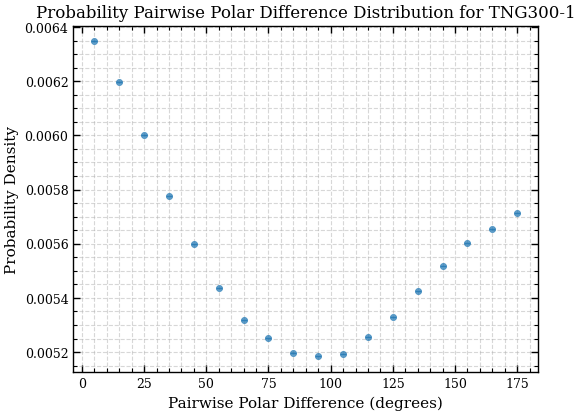

In [10]:
prob_polar_plotter = AstroPlotter()
prob_polar_plotter.scatter_plot(
    polar_bin_centers, 
    pairwise_polar_differences,
    errorBars = pairwise_polar_errorbars,
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for {sim}',
    # ylim = (0, 0.01),
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_{sim}.png',
    grid=True,
)

In [11]:
# save bin centers and probabilities to text file
output_data_file = scratchDataDirc + f'/pairwise_polar/pairwise_polar_difference_{sim}.txt'
# print(f"data to be saved: {np.column_stack((polar_bin_centers, pairwise_polar_differences))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers, pairwise_polar_differences)), header='Pairwise Polar Difference (degrees)    Probability Density')

## Make plots for Mean Resultant Length (MRL) directionality

In [12]:
_ = filtered_list_of_galaxy_groups.compute_all_MRL_directionality(parallelize=False, tempSaveDir=f'{scratchDataDirc}/MRL_directionality', rewrite=generalRewrite)

Resuming from existing temp file: MRL_values_280.hdf5

Final save after processing all galaxy groups.


In [13]:
print(len(filtered_list_of_galaxy_groups.MRL_values))

600


In [14]:
MRL_bin_centers, MRL_directionality, MRL_errorbars = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False, tempSaveDir=f'{scratchDataDirc}/MRL_directionality')
print('Computed MRL directionality for galaxy groups.')


Using pre-computed MRL directionality values.
Computed MRL directionality for galaxy groups.


warning ax is none
0.7
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL/MRL_directionality_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Probability MRL Directionality Distribution for TNG300-1'}, xlabel='MRL Directionality', ylabel='Probability Density'>)

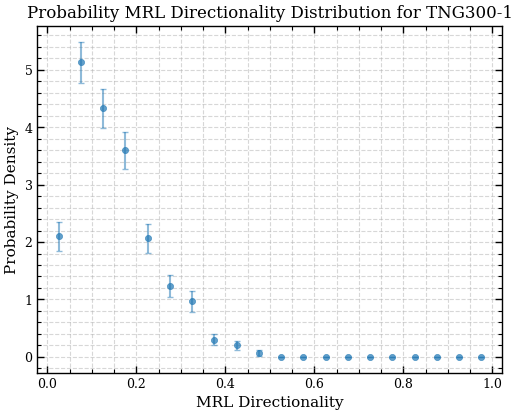

In [15]:
prob_MRL_plotter = AstroPlotter()
prob_MRL_plotter.scatter_plot(
    MRL_bin_centers, 
    MRL_directionality,
    errorBars = MRL_errorbars,
    xlabel='MRL Directionality',
    ylabel='Probability Density',
    title=f'Probability MRL Directionality Distribution for {sim}',
    # ylim=(0,4)
    output_filename=scratchPlotDirc + f'/MRL/MRL_directionality_{sim}.png',
    grid=True
)

In [16]:
#save bin centers and probabilities to text file
output_data_file_MRL = scratchDataDirc + f'/MRL_directionality/MRL_directionality_{sim}.txt'
# print(f"data to be saved: {np.column_stack((MRL_bin_centers, MRL_directionality))}")
np.savetxt(output_data_file_MRL, np.column_stack((MRL_bin_centers, MRL_directionality)), header='MRL Directionality    Probability Density')

In [17]:
#save bin MRL values to text file
output_data_file_MRL = scratchDataDirc + f'/MRL_directionality/MRL_directionality_RAW_{sim}.txt'
# print(f"data to be saved: {np.vstack(filtered_list_of_galaxy_groups.MRL_values)}")
np.savetxt(output_data_file_MRL, np.vstack(filtered_list_of_galaxy_groups.MRL_values), header='MRL Directionality')

## make plots for red vs blue galaxies

In [ ]:
filteredRedGalaxies = filtered_list_of_galaxy_groups.filterSubhalos(redGalaxies=True)
filtered_red_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = filtered_list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filteredRedGalaxies)
print(f'Number of galaxy groups with only red satellites: {filtered_red_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

filteredBlueGalaxies = filtered_list_of_galaxy_groups.filterSubhalos(blueGalaxies=True)
filtered_blue_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = filtered_list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filteredBlueGalaxies)
print(f'Number of galaxy groups with only blue satellites: {filtered_blue_list_of_galaxy_groups.getRangeOfNumSubhalos()}')


_ = filtered_red_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_color/pairwise_polar_red', rewrite=generalRewrite)
_ = filtered_blue_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_color/pairwise_polar_blue', rewrite=generalRewrite)


In [ ]:
polar_bin_centers_red, pairwise_polar_differences_red, pairwise_polar_red_errorbars = filtered_red_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_red')
polar_bin_centers_blue, pairwise_polar_differences_blue, pairwise_polar_blue_errorbars = filtered_blue_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_blue')

In [ ]:
print('Computed pairwise polar differences between red and blue satellite galaxies.')
prob_polar_red_blue_plotter = AstroPlotter()
prob_polar_red_blue_fig, prob_polar_red_blue_ax = prob_polar_red_blue_plotter.create_figure()
prob_polar_red_blue_plotter.scatter_plot(
    polar_bin_centers_red, 
    pairwise_polar_differences_red,
    ax=prob_polar_red_blue_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for Red and Blue Satellites in {sim}',
    # ylim = (0, 0.01),
    c=['red'],
    errorBars = pairwise_polar_red_errorbars,
    label = "Red Galaxies (g-r) ≥ 0.65",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_red_blue_plotter.scatter_plot(
    polar_bin_centers_blue, 
    pairwise_polar_differences_blue,
    ax=prob_polar_red_blue_ax,  # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for Red and Blue Satellites in {sim}',
    # ylim = (0, 0.01),
    c=['blue'],
    errorBars = pairwise_polar_blue_errorbars,
    label = "Blue Galaxies (g-r) < 0.65",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_red_blue_{sim}.png',
    grid=True,
)

In [ ]:
# save as txt file
output_data_file = scratchDataDirc + f'/pairwise_polar_color/pairwise_polar_color_difference_{sim}.txt'
print(f"data to be saved: {np.column_stack((polar_bin_centers_red, pairwise_polar_differences_red, pairwise_polar_differences_blue))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers_red, pairwise_polar_differences_red, pairwise_polar_differences_blue)), header='Pairwise Polar Difference (degrees)    Probability Density (Red)    Probability Density (Blue)')

## make plots for 150 vs 50 member galaxies

In [ ]:
filteredGT150 = filtered_list_of_galaxy_groups.filterSubhalos(minNumGalaxies=150)
filtered_GT150_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = filtered_list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filteredGT150)
print(f'Number of galaxy groups with more than 150 satellites: {filtered_GT150_list_of_galaxy_groups.getNumGalaxyGroups()}')
filteredLT50 = filtered_list_of_galaxy_groups.filterSubhalos(maxNumGalaxies=50)
filtered_LT50_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = filtered_list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filteredLT50)
print(f'Number of galaxy groups with less than 50 satellites: {filtered_LT50_list_of_galaxy_groups.getNumGalaxyGroups()}')

_ = filtered_GT150_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_memberNum/pairwise_polar_GT150', rewrite=generalRewrite)
_ = filtered_LT50_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_memberNum/pairwise_polar_LT50', rewrite=generalRewrite)

In [ ]:
print('Computed pairwise polar differences for galaxy groups with >150 and <50 satellites.')
polar_bin_centers_GT150, pairwise_polar_differences_GT150, pairwise_polar_GT150_errorbars = filtered_GT150_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_GT150')
polar_bin_centers_LT50, pairwise_polar_differences_LT50, pairwise_polar_LT50_errorbars = filtered_LT50_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_LT50')

In [ ]:
prob_polar_GT150_LT50_plotter = AstroPlotter()
prob_polar_GT150_LT50_fig, prob_polar_GT150_LT50_ax = prob_polar_GT150_LT50_plotter.create_figure()
prob_polar_GT150_LT50_plotter.scatter_plot(
    polar_bin_centers_GT150, 
    pairwise_polar_differences_GT150,
    errorBars = pairwise_polar_GT150_errorbars,
    ax=prob_polar_GT150_LT50_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for >150 and <50 Satellites in {sim}',
    # ylim = (0, 0.01),
    label="More than 150 members",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_GT150_LT50_plotter.scatter_plot(
    polar_bin_centers_LT50, 
    pairwise_polar_differences_LT50,
    errorBars = pairwise_polar_LT50_errorbars,
    ax=prob_polar_GT150_LT50_ax,  # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for >150 and <50 Satellites in {sim}',
    # ylim = (0, 0.01),
    label="Less than 50 members",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_GT150_LT50_{sim}.png',
    grid=True,
)

In [ ]:
# save as text file
output_data_file = scratchDataDirc + f'/pairwise_polar_memberNum/pairwise_polar_memberNum_difference_{sim}.txt'
# print(f"data to be saved: {np.column_stack((polar_bin_centers_LT50, pairwise_polar_differences_LT50, pairwise_polar_differences_GT150))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers_LT50, pairwise_polar_differences_LT50, pairwise_polar_differences_GT150)), header='Pairwise Polar Difference (degrees)    Probability Density (<50 Satellites)    Probability Density (>150 Satellites)')

## make plots for <35% vs >65% R200 plots

In [ ]:
filteredLT35R200 = filtered_list_of_galaxy_groups.filterSubhalos(withinXPercentR200=[0,0.35])
filtered_LT35R200_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = filtered_list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filteredLT35R200)
print(f'Number of galaxy groups with satellites within 35% R200: {filtered_LT35R200_list_of_galaxy_groups.getNumGalaxyGroups()}')
filtered_GT65R200 = filtered_list_of_galaxy_groups.filterSubhalos(withinXPercentR200=[0.65,1.00])
filtered_GT65R200_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = filtered_list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_GT65R200)
print(f'Number of galaxy groups with satellites within 65-100% R200: {filtered_GT65R200_list_of_galaxy_groups.getNumGalaxyGroups()}')

_ = filtered_LT35R200_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_radius/pairwise_polar_LT35R200', rewrite=generalRewrite)
_ = filtered_GT65R200_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_radius/pairwise_polar_GT65R200', rewrite=generalRewrite)

In [ ]:
polar_bin_centers_LT35R200, pairwise_polar_differences_LT35R200, pairwise_polar__LT35R400_errorbars = filtered_LT35R200_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_LT35R200')
polar_bin_centers_GT65R200, pairwise_polar_differences_GT65R200, pairwise_polar_GT65R200_errorbars = filtered_GT65R200_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_GT65R200')

In [ ]:
prob_polar_LT35R200_GT65R200_plotter = AstroPlotter()
prob_polar_LT35R200_GT65R200_fig, prob_polar_LT35R200_GT65R200_ax = prob_polar_LT35R200_GT65R200_plotter.create_figure()
prob_polar_LT35R200_GT65R200_plotter.scatter_plot(
    polar_bin_centers_LT35R200, 
    pairwise_polar_differences_LT35R200,
    errorBars = pairwise_polar__LT35R400_errorbars,
    ax=prob_polar_LT35R200_GT65R200_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for 65%<r<100% R200 and 0%<r<35% R200 in {sim}',
    # ylim = (0, 0.01),
    label="0<r<0.35 R200",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_LT35R200_GT65R200_plotter.scatter_plot(
    polar_bin_centers_GT65R200, 
    pairwise_polar_differences_GT65R200,
    errorBars = pairwise_polar_GT65R200_errorbars,
    ax=prob_polar_LT35R200_GT65R200_ax,  # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for \n 65%<r<100% R200 and 0%<r<35% R200 in {sim}',
    # ylim = (0, 0.01),
    label="0.65<r<1.00 R200",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_LT35R200_GT65R200_{sim}.png',
    grid=True,
)

In [ ]:
# save as text file
output_data_file = scratchDataDirc + f'/pairwise_polar_radius/pairwise_polar_radius_difference_{sim}.txt'
# print(f"data to be saved: {np.column_stack((polar_bin_centers_LT35R200, pairwise_polar_differences_LT35R200, pairwise_polar_differences_GT65R200))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers_LT35R200, pairwise_polar_differences_LT35R200, pairwise_polar_differences_GT65R200)), header='Pairwise Polar Difference (degrees)    Probability Density (<35% R200)    Probability Density (65-100% R200)')

## check central-FoF distance offests

In [ ]:
#save txt file if most massive != most central
#with lines:
# 1: x_cm of the halo
# 2: y_cm of the halo
# 3: z_cm of the halo
# 4: offset of the "most central galaxy" from the halo center of mass
# 5: ratio of the total masses of the most central and most massive galaxoes
# 6: offset of the most massive galaxy from the halo center of mass

with open(scratchDataDirc + f'/most_massive_vs_most_central/most_massive_vs_most_central_{sim}.txt', 'w') as f:
    f.write('x_cm    y_cm    z_cm    offset_most_central    mass_ratio    offset_most_massive most_massive_r_ratio_r200\n')
    
for galaxy_group in list_of_galaxy_groups.getAllGalaxyGroups():
    if galaxy_group.getMostMassiveSubhalo().getIdx() != galaxy_group.getMostCentralSubhalo().getIdx():
        output_data_file = scratchDataDirc + f'/most_massive_vs_most_central/most_massive_vs_most_central_{sim}.txt'
        with open(output_data_file, 'a') as f:
            x_cm, y_cm, z_cm = galaxy_group.getPos()
            most_central_pos = galaxy_group.getMostCentralSubhalo().getPosition()
            most_massive_pos = galaxy_group.getMostMassiveSubhalo().getPosition()
            offset_most_central = np.linalg.norm(most_central_pos - galaxy_group.getPos())
            offset_most_massive = np.linalg.norm(most_massive_pos - galaxy_group.getPos())
            mass_ratio = galaxy_group.getMostCentralSubhalo().getStellarMass() / galaxy_group.getMostMassiveSubhalo().getStellarMass()
            most_massive_r_ratio_r200 = np.linalg.norm(galaxy_group.getMostMassiveSubhalo().getPosition()) / galaxy_group.getRCrit200()
            f.write(f"{x_cm} {y_cm} {z_cm} {offset_most_central} {mass_ratio} {offset_most_massive} {most_massive_r_ratio_r200} \n")

In [12]:
#filter to groups with stellar mass < 10^{14} Msun
filtered_13_14_galaxy_groups = list_of_galaxy_groups.filterSubhalos(maxGGMass=1e14)
# print(f"len filtered: {len(filtered_galaxy_groups)}")
filtered_13_14_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_13_14_galaxy_groups)

total to process: 3732


In [13]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {filtered_13_14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {filtered_13_14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {filtered_13_14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {filtered_13_14_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 3452
Number of subhalos in GG 0: 23
Number of subhalos in GG 10: 16
 Range of satellites: (1, 59)


In [14]:
def getCentral_FoF_distanceOffset(list_of_galaxy_groups : ListGalaxyGroup):
    distanceOffsets = []
    central_positions = []
    FoF_positions = []
    for gg in list_of_galaxy_groups.listGalaxyGroups:
        central_subhalo = gg.getCentralSubhalo()
        fof_center = gg.getPos()
        central_positions.append(central_subhalo.getPosition())
        FoF_positions.append(fof_center)
        
        distanceOffsets.append(np.linalg.norm(central_subhalo.getPosition() - fof_center))
    return np.array(distanceOffsets), np.array(central_positions), np.array(FoF_positions)

In [15]:
distances_gt13_ls14 = getCentral_FoF_distanceOffset(filtered_13_14_list_of_galaxy_groups)[0]
print(distances_gt13_ls14)
distances_gt14 = getCentral_FoF_distanceOffset(filtered_list_of_galaxy_groups)[0]


[0. 0. 0. ... 0. 0. 0.]


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/central_disparities/central_FoF_distance_TNG300-1_lt14.png
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/central_disparities/central_FoF_distance_TNG300-1_gt14.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Distance between Central Subhalo and Galaxy Group Position for TNG300-1'}, xlabel='Distance between Central Subhalo and Galaxy Group Position (kpc)', ylabel='Density of Galaxy Groups'>)

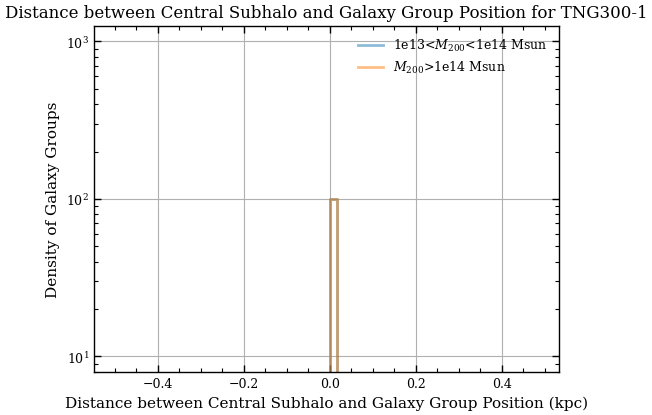

In [16]:
central_FoF_Plotter = AstroPlotter()
central_FoF_fig, central_FoF_ax = central_FoF_Plotter.create_figure()
central_FoF_Plotter.histogram(
    distances_gt13_ls14,
    bins=60, #np.logspace(np.log10(0.1), np.log10(5000), 60),
    ax = central_FoF_ax,  # Use the same axis for overlay
    xlabel='Distance between Central Subhalo and Galaxy Group Position (kpc)',
    ylabel='Density of Galaxy Groups',
    title=f'Distance between Central Subhalo and Galaxy Group Position for {sim} ($M_{{200}}$<1e14 Msun)',
    label='1e13<$M_{{200}}$<1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/central_FoF_distance_{sim}_lt14.png',
    percentage=True,
    grid=True,
)
central_FoF_Plotter.histogram(
    distances_gt14,
    bins=60, #np.logspace(np.log10(0.1), np.log10(5000), 60),
    ax = central_FoF_ax,  # Use the same axis for overlay
    xlabel='Distance between Central Subhalo and Galaxy Group Position (kpc)',
    ylabel='Density of Galaxy Groups',
    title=f'Distance between Central Subhalo and Galaxy Group Position for {sim}',
    label='$M_{{200}}$>1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/central_FoF_distance_{sim}_gt14.png',
    percentage=True,
    grid=True,
)

In [17]:
#make pairwise polar difference plots for these two mass bins as well
_ = filtered_13_14_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False)
_ = filtered_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False)

Total Galaxy Groups to process: 3452 with pairs : 481491
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6615Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210

In [18]:
polar_bin_centers_13_14, pairwise_polar_differences_13_14, pairwise_polar_13_14_errorbars = filtered_13_14_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False)

In [19]:
polar_bin_centers_gt14, pairwise_polar_differences_gt14, pairwise_polar_gt14_errorbars = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False)

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/pairwise_polar/pairwise_polar_difference_gt14_lt14_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for 1e13<$M_{200}$<1e14 and $M_{200}$>1e14 Msun in TNG300-1'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

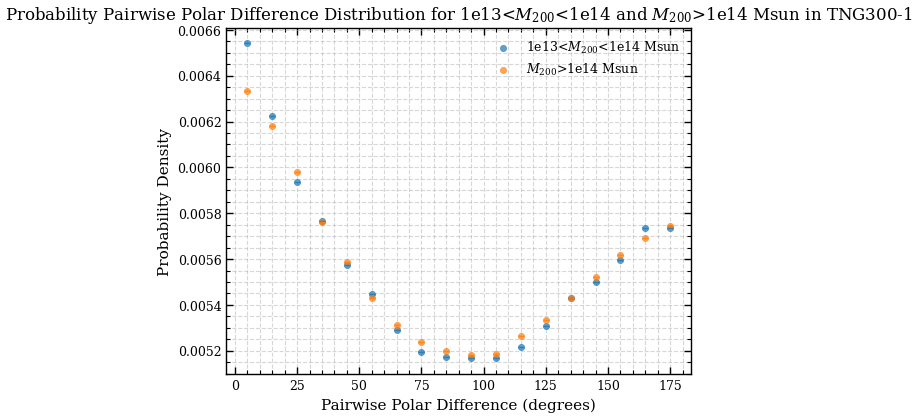

In [20]:
prob_polar_gt14_lt14_plotter = AstroPlotter()
prob_polar_gt14_lt14_fig, prob_polar_gt14_lt14_ax = prob_polar_gt14_lt14_plotter.create_figure()
prob_polar_gt14_lt14_plotter.scatter_plot(
    polar_bin_centers_13_14, 
    pairwise_polar_differences_13_14,
    errorBars = pairwise_polar_13_14_errorbars,
    ax=prob_polar_gt14_lt14_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for 1e13<$M_{{200}}$<1e14 and $M_{{200}}$>1e14 Msun in {sim}',
    # ylim = (0, 0.01),
    label="1e13<$M_{{200}}$<1e14 Msun",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_gt14_lt14_plotter.scatter_plot(
    polar_bin_centers_gt14, 
    pairwise_polar_differences_gt14,
    errorBars = pairwise_polar_gt14_errorbars,
    ax=prob_polar_gt14_lt14_ax,  # Use the same axis for        overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for 1e13<$M_{{200}}$<1e14 and $M_{{200}}$>1e14 Msun in {sim}',
    # ylim = (0, 0.01),
    label="$M_{{200}}$>1e14 Msun",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_gt14_lt14_{sim}.png',
    grid=True,
)

## prob distribution of mass of five subgroups
13-13.5, 13.5-14, 14-14.5, 14.5-15, >15

In [28]:
#filter to groups with stellar mass 10^{13} < $M_{{200}}$ < 10^{13.5} Msun
filtered_13_13p5_GG = list_of_galaxy_groups.filterSubhalos(maxGGMass=5e13, minGGMass=1e13)
for gg in list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
    # else:
    #     print(gg.getMostMassiveSubhalo().getPosition(), gg.getMostCentralSubhalo().getPosition())
print(num_mostMassiveNotCentral)
filtered_13_13p5_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_13_13p5_GG)

#filter to groups with stellar mass 10^{13.5} < $M_{{200}}$ < 10^{14} Msun
filtered_13p5_14_GG = list_of_galaxy_groups.filterSubhalos(maxGGMass=1e14, minGGMass=5e13)
filtered_13p5_14_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_13p5_14_GG)

#filter to groups with stellar mass 10^{14} < $M_{{200}}$ < 10^{14.5} Msun
filtered_14_14p5_GG = list_of_galaxy_groups.filterSubhalos(maxGGMass=5e14, minGGMass=1e14)
filtered_14_14p5_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_14_14p5_GG)

#filter to groups with stellar mass 10^{14.5} < $M_{{200}}$ < 10^{15} Msun
filtered_14p5_15_GG = list_of_galaxy_groups.filterSubhalos(maxGGMass=1e15, minGGMass=5e14)
filtered_14p5_15_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_14p5_15_GG)

#filter to groups with stellar mass $M_{{200}}$ > 10^{15} Msun
filtered_gt15_GG = list_of_galaxy_groups.filterSubhalos(minGGMass=1e15)
filtered_gt15_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = list_of_galaxy_groups.getHeaderInformation, listGalaxyGroups=filtered_gt15_GG)


total to process: 3732
0rogress: Processing Galaxy Group ID 3732 / 3732
total to process: 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [25]:
print(f'Number of galaxy groups 13-13.5 loaded: {filtered_13_13p5_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups 13.5-14 loaded: {filtered_13p5_14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups 14-14.5 loaded: {filtered_14_14p5_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups 14.5-15 loaded: {filtered_14p5_15_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups >15 loaded: {filtered_gt15_list_of_galaxy_groups.getNumGalaxyGroups()}')

print(f"total number of galaxy groups: {filtered_13_13p5_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_13p5_14_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_14_14p5_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_14p5_15_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_gt15_list_of_galaxy_groups.getNumGalaxyGroups()}")

#print the num of galaxies in each group where the central is not the most massive
num_mostMassiveNotCentral = 0
for gg in filtered_13_13p5_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
    else:
        print(gg.getMostMassiveSubhalo().getPosition(), gg.getMostCentralSubhalo().getPosition())
print(f"Number of groups with most massive not central in 13-13.5 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_13p5_14_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in 13.5-14 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_14_14p5_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in 14-14.5 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_14p5_15_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in 14.5-15 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_gt15_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in >15 bin: {num_mostMassiveNotCentral}")
        

Number of galaxy groups 13-13.5 loaded: 3032
Number of galaxy groups 13.5-14 loaded: 420
Number of galaxy groups 14-14.5 loaded: 268
Number of galaxy groups 14.5-15 loaded: 9
Number of galaxy groups >15 loaded: 3
total number of galaxy groups: 3732
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0.

In [ ]:
#plot the mass ratio distribution (most central / most massive) for these mass bins
prob_mass_ratio_plotter = AstroPlotter()
prob_mass_ratio_fig, prob_mass_ratio_ax = prob_mass_ratio_plotter.create_figure()
bins = np.linspace(0.4, 1, 30)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_13_13p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e13<$M_{{200}}$<1e13.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_13p5_14_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e13.5<$M_{{200}}$<1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_14_14p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e14<$M_{{200}}$<1e14.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_14p5_15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e14.5<$M_{{200}}$<1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_gt15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio ($M_{{central}} / M_{{most massive}}$)',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='$M_{{200}}$>1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/most_massive_vs_most_central_massRatio_{sim}_massBins.png',
    percentage=True,
    grid=True,
)

In [ ]:
# plot the r/r200 of the most massive subhalo for these mass bins
prob_massive_r_ratio_plotter = AstroPlotter()
prob_massive_r_ratio_fig, prob_massive_r_ratio_ax = prob_massive_r_ratio_plotter.create_figure()
bins = np.linspace(0, 1, 30)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_13_13p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e13<$M_{{200}}$<1e13.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_13p5_14_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e13.5<$M_{{200}}$<1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_14_14p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e14<$M_{{200}}$<1e14.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_14p5_15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e14.5<$M_{{200}}$<1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_gt15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='$M_{{200}}$>1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/most_massive_r_ratio_r200_{sim}_massBins.png',
    percentage=True,
    grid=True,
)

In [29]:
# plot the median number of subhalos within r200 for these mass bins
def plot_median_num_subhalos_by_mass_bins(listGG : list[tuple[ListGalaxyGroup, str]]):
    median_subhalo_plotter = AstroPlotter()
    median_subhalo_fig, median_subhalo_ax = median_subhalo_plotter.create_figure()
    bins = np.linspace(0, 500, 100)
    mass_bin_labels = []
    for i, (mass_filtered_list, mass_bin_label) in enumerate(listGG):
        median_num_subhalos = []
        for galaxy_group in mass_filtered_list.getAllGalaxyGroups():
            median_num = len(galaxy_group.getSatelliteSubhalos())
            median_num_subhalos.append(median_num)
        mass_bin_labels.append(mass_bin_label)
        print(f"Mass bin: {mass_bin_label}, median number of subhalos: {median_num}")
    
        median_subhalo_plotter.histogram(
            median_num_subhalos,
            bins=bins,
            ax= median_subhalo_ax,
            xlabel='Number of Satellite Subhalos within r200',
            ylabel='Density of Galaxy Groups',
            title=f'Number of Satellite Subhalos within r200 for {sim}',
            label=mass_bin_label,
            ylog=True,
            legend=True,
            linealpha=0.5,
            output_filename=None,
            percentage=True,
            grid=True,
        )
    median_subhalo_plotter.save_figure(
        fig=median_subhalo_fig,
        filename=scratchPlotDirc + f'/median_num_subhalos_by_mass_bins_{sim}.png'
    )

In [ ]:
plot_median_num_subhalos_by_mass_bins([(filtered_13_13p5_list_of_galaxy_groups, '1e13<$M_{{200}}$<1e13.5 Msun'),
                                       (filtered_13p5_14_list_of_galaxy_groups, '1e13.5<$M_{{200}}$<1e14 Msun'),
                                       (filtered_14_14p5_list_of_galaxy_groups, '1e14<$M_{{200}}$<1e14.5 Msun'),
                                       (filtered_14p5_15_list_of_galaxy_groups, '1e14.5<$M_{{200}}$<1e15 Msun'),
                                       (filtered_gt15_list_of_galaxy_groups, '$M_{{200}}$>1e15 Msun')]) 

In [30]:
#plot the pairwise polar differences for these mass bins and split between central is most massive or not
def plot_pairwise_polar_by_mass_bins_and_centralMassive_status(listGG : list[tuple[ListGalaxyGroup, str]]): #mass_filtered_list : ListGalaxyGroup, mass_bin_label):
    prob_polar_mass_plotter = AstroPlotter()
    prob_polar_mass_fig, prob_polar_mass_ax = prob_polar_mass_plotter.create_figure(ncols=1, nrows=len(listGG), figsize=(8, 6*len(listGG)))

    colors = ['blue', 'orange', 'red', 'green', 'purple']                                                          
    for i, (mass_filtered_list, mass_bin_label) in enumerate(listGG):
        central_most_massive = mass_filtered_list.filterSubhalos(centralIsMostMassive=True)
        not_central_most_massive = mass_filtered_list.filterSubhalos(centralIsMostMassive=False)
        print(f"len subhalos: {len(central_most_massive), len(not_central_most_massive)}")
        central_most_massive_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = mass_filtered_list.getHeaderInformation(), listGalaxyGroups=central_most_massive)
        not_central_most_massive_list_of_galaxy_groups = ListGalaxyGroup(headerInformation = mass_filtered_list.getHeaderInformation(), listGalaxyGroups=not_central_most_massive)
        
        central_most_massive_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False)
        not_central_most_massive_list_of_galaxy_groups.compute_all_pairwise_polar_differences(parallelize=False)
        mass_filtered_list.compute_all_pairwise_polar_differences(parallelize=False)
        
        polar_bin_centers_centralMassive, pairwise_polar_differences_centralMassive, pairwise_polar_centralMassive_errorbars = central_most_massive_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False)
        polar_bin_centers_notCentralMassive, pairwise_polar_differences_notCentralMassive, pairwise_polar_notCentralMassive_errorbars = not_central_most_massive_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False)
        polar_bin_centers_total, pairwise_polar_differences_total, pairwise_polar_total_errorbars = mass_filtered_list.compute_probablity_distribution_of_polar_differences(bins = np.arange(0, 185, 10), parallelize=False)
    
        if len(listGG) > 1:
            print(f"choosing ax, {i}")
            axToPlot = prob_polar_mass_ax[i]
        else:
            axToPlot = prob_polar_mass_ax
        print(f"len: {len(polar_bin_centers_centralMassive), len(polar_bin_centers_notCentralMassive), len(polar_bin_centers_total)}")
        print(f"first 5 values centralMassive: {pairwise_polar_differences_centralMassive[:5]}, notCentralMassive: {pairwise_polar_differences_notCentralMassive[:5]}, total: {pairwise_polar_differences_total[:5]}")

        prob_polar_mass_plotter.scatter_plot(
            polar_bin_centers_centralMassive, 
            pairwise_polar_differences_centralMassive,
            # errorBars = pairwise_polar_centralMassive_errorbars,
            ax=axToPlot, # Use the same axis for overlay
            overlay_color=colors[0],
            # xlabel='Pairwise Polar Difference (degrees)',
            # ylabel='Probability Density',
            # title=f'Probability Pairwise Polar Difference Distribution for {sim} ({mass_bin_label})',
            # ylim = (0, 0.01),
            label="Central is Most Massive",
            # output_filename=None,  # Disable saving for combined plot
            # grid=True,
        )
        prob_polar_mass_plotter.scatter_plot(
            polar_bin_centers_notCentralMassive, 
            pairwise_polar_differences_notCentralMassive,
            # errorBars = pairwise_polar_notCentralMassive_errorbars,
            ax=axToPlot,  # Use the same axis for overlay
            overlay_color=colors[1], 
            # xlabel='Pairwise Polar Difference (degrees)',
            # ylabel='Probability Density',
            # title=f'Probability Pairwise Polar Difference Distribution for {sim} ({mass_bin_label})',
            # ylim = (0, 0.01),
            label="Central is NOT Most Massive",
            # include_legend=True,
            # output_filename=None,
            # grid=True,
        )
        prob_polar_mass_plotter.scatter_plot(
            polar_bin_centers_total, 
            pairwise_polar_differences_total,
            # errorBars = pairwise_polar_total_errorbars,
            ax=axToPlot,  # Use the same axis for overlay
            overlay_color=colors[2],
            xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for {sim} ({mass_bin_label})',
            # ylim = (0, 0.01),
            s=10,
            
            label="All Galaxy Groups",
            include_legend=True,
            # output_filename=scratchPlotDirc + f'/pairwise_polar_difference_total_{mass_bin_label.replace("<","lt").replace(">","gt")}_{sim}.png',
            grid=True,
        )

        
    return prob_polar_mass_plotter, prob_polar_mass_fig, prob_polar_mass_ax

total to process: 3032
total to process: 3032alaxy Group ID 3032 / 3032
len subhalos: (3032, 0)laxy Group ID 3032 / 3032
Total Galaxy Groups to process: 3032 with pairs : 228318
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6615Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 3032 with pairs : 228318
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6615Total Galaxy Groups to process: 0 with pairs : 0
choosing ax, 0
len: (18, 18, 18)
first 5 values centralMassive: [0.00678285 0.00634416 0.00594791 0.00577659 0.00554828], notCentralMassive: [nan nan nan nan nan], total: [0.00678285 0.00634416 0.00594791 0.00577659 0.00554828]
total to process: 420
total to process: 420Galaxy Group ID 420 / 420
len subhalos: (420, 0)alaxy Group ID 420 / 420
Total Galaxy Groups to process: 420 with pairs : 253173
Progress: Processing Galaxy Group ID 102 / 420

/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:229: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 23/23 in Galaxy Group ID 946 with total pairs 2535Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 420 with pairs : 253173
Processing Subhalo 23/23 in Galaxy Group ID 946 with total pairs 2535Total Galaxy Groups to process: 0 with pairs : 0
choosing ax, 1
len: (18, 18, 18)
first 5 values centralMassive: [0.00634162 0.00612875 0.00592731 0.00575805 0.00559881], notCentralMassive: [nan nan nan nan nan], total: [0.00634162 0.00612875 0.00592731 0.00575805 0.00559881]
total to process: 268
total to process: 268Galaxy Group ID 268 / 268
len subhalos: (268, 0)alaxy Group ID 268 / 268
Total Galaxy Groups to process: 268 with pairs : 1220564
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 268 with pairs : 1220564
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210Total Galaxy Groups to process: 0 with pairs : 0
choosing a

(<myproject.utilities.plottingTools.AstroPlotter at 0x14fe58222780>,
 <Figure size 800x3000 with 5 Axes>,
 array([<Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e13<$M_{{200}}$<1e13.5 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e13.5<$M_{{200}}$<1e14 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e14<$M_{{200}}$<1e14.5 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e14.5<$M_{{200}}$<1e15 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Di

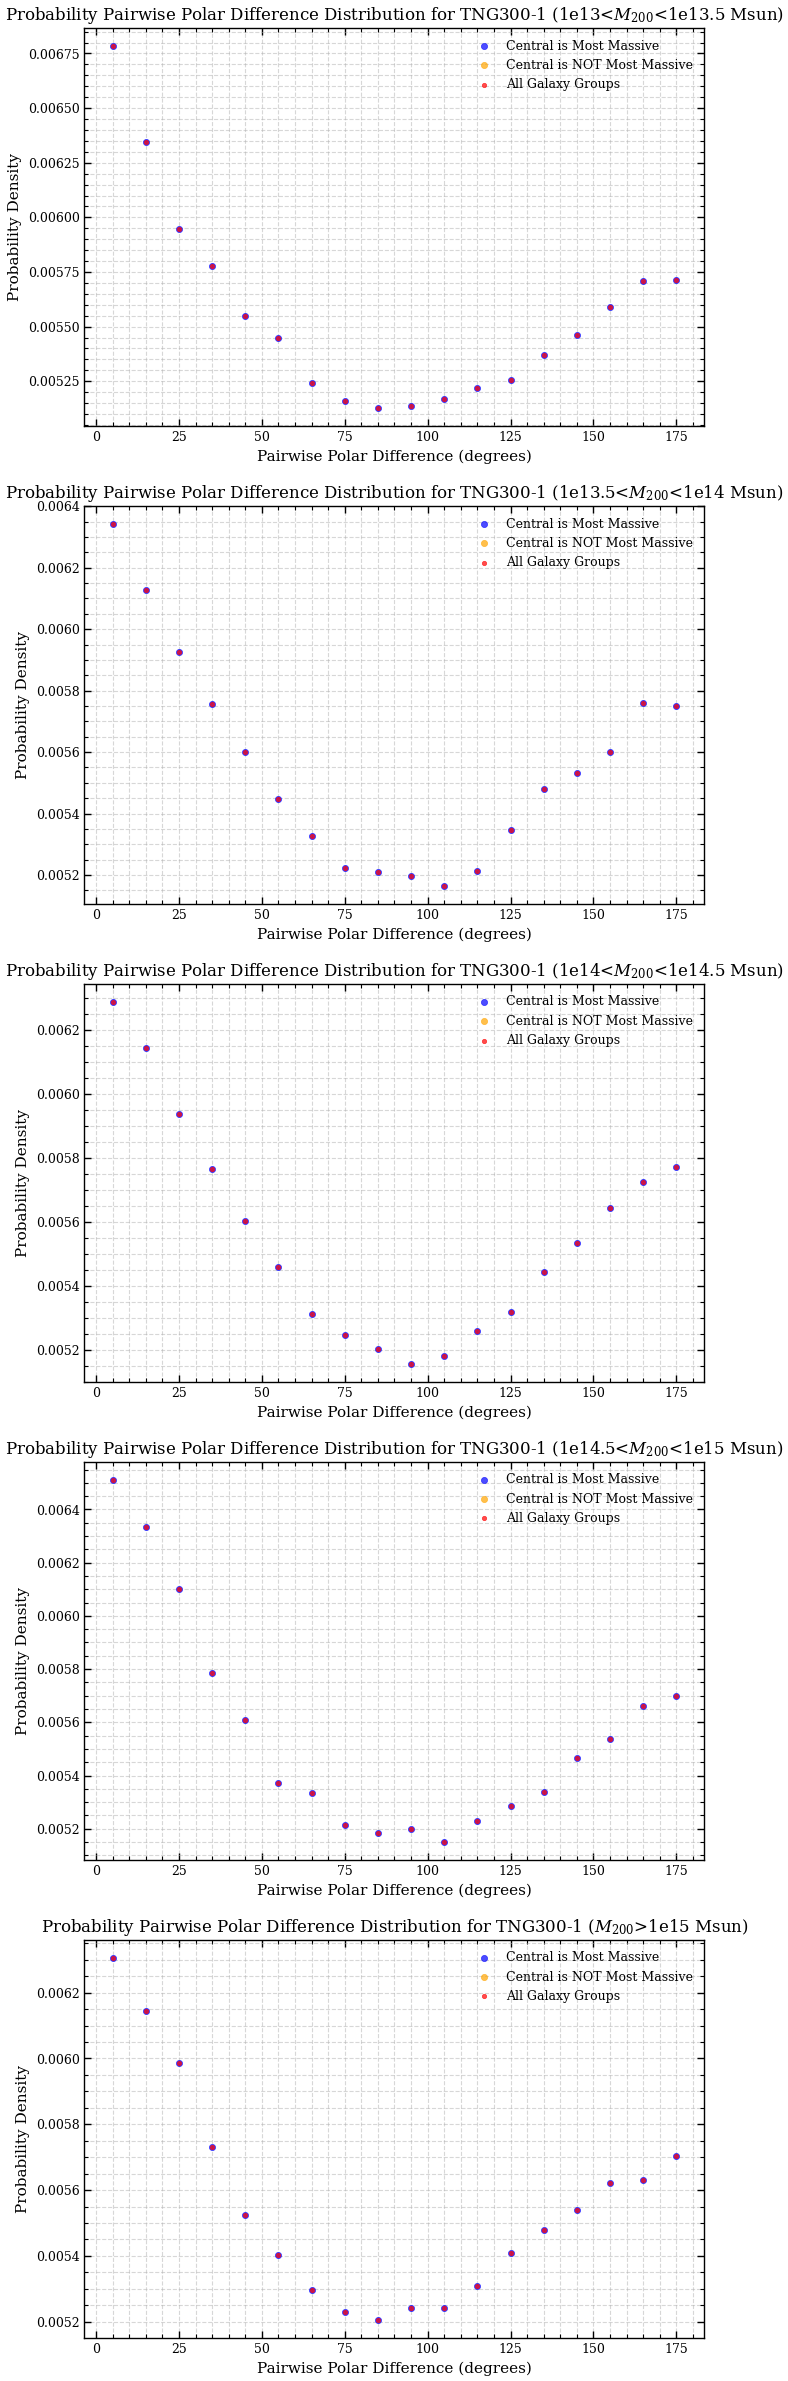

In [31]:
# run for each mass bin
plot_pairwise_polar_by_mass_bins_and_centralMassive_status([(filtered_13_13p5_list_of_galaxy_groups, '1e13<$M_{{200}}$<1e13.5 Msun'),
                                                            (filtered_13p5_14_list_of_galaxy_groups, '1e13.5<$M_{{200}}$<1e14 Msun'),
                                                            (filtered_14_14p5_list_of_galaxy_groups, '1e14<$M_{{200}}$<1e14.5 Msun'),
                                                            (filtered_14p5_15_list_of_galaxy_groups, '1e14.5<$M_{{200}}$<1e15 Msun'),
                                                            (filtered_gt15_list_of_galaxy_groups, '$M_{{200}}$>1e15 Msun')])
# plot_pairwise_polar_by_mass_bins_and_centralMassive_status([
#                                                             (filtered_gt15_list_of_galaxy_groups, '$M_{{200}}$>1e15 Msun')])

In [ ]:
#plot for all galaxy groups with central most massive vs not central most massive without splitting into mass bins
prob_polar_mass_plotter, prob_polar_mass_fig, prob_polar_mass_ax = plot_pairwise_polar_by_mass_bins_and_centralMassive_status([(list_of_galaxy_groups, '$M_{{200}}$>1e13 Msun')])

In [ ]:
#replot this with different ylims
prob_polar_mass_ax.set_ylim(0.0050, 0.0065)
prob_polar_mass_plotter.save_figure(prob_polar_mass_fig, scratchPlotDirc + f'/pairwise_polar_difference_allMasses_{sim}_differentYlim.png')

#overlay
# polar_bin_centers, pairwise_polar_differences, pairwise_polar_errorbars
prob_polar_mass_ax.errorbar(polar_bin_centers, pairwise_polar_differences, yerr=pairwise_polar_errorbars, fmt='o', label='All Galaxy Groups', color='black', markersize=3, alpha=0.5)
prob_polar_mass_ax.legend()
prob_polar_mass_plotter.save_figure(prob_polar_mass_fig, scratchPlotDirc + f'/pairwise_polar_difference_allMasses_{sim}_overlay.png')

## create MRL random distribution curves

200 200
[0.08       0.24       0.44       0.70666667 0.93333333 1.06666667
 1.18666667 1.47333333 1.34666667 1.83333333 1.88       2.12666667
 2.08666667 2.36666667 2.6        2.57333333 2.76666667 3.03333333
 3.13333333 3.01333333 3.50666667 3.39333333 3.3        3.51333333
 3.54666667 3.46       3.71333333 3.54666667 3.71333333 3.97333333
 3.73333333 3.91333333 3.78       3.87333333 3.59333333 3.75333333
 3.56666667 3.79333333 3.8        3.73333333 3.43333333 3.62666667
 3.6        3.5        3.54       3.24666667 3.08       2.99333333
 3.16       3.12666667 3.13333333 2.84       2.76666667 2.62666667
 2.56666667 2.46666667 2.33333333 2.08666667 2.21333333 2.08666667
 2.1        2.         1.82666667 1.8        1.49333333 1.64666667
 1.56666667 1.45333333 1.42       1.14       1.26666667 1.16666667
 1.26       0.96       1.04       0.84666667 0.93333333 0.67333333
 0.71333333 0.62666667 0.61333333 0.54666667 0.52       0.5
 0.42       0.51333333 0.46666667 0.34       0.38       0.306

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:244: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k-', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL_distribution_curves_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'MRL Distribution Curves'}, xlabel='MRL Directionality', ylabel='Probability Density'>)

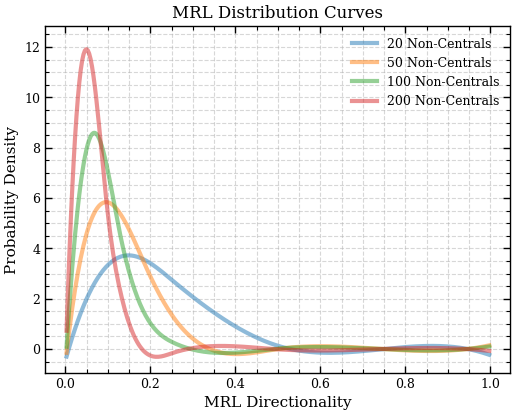

In [18]:
MRL_20, MRL_20_bin_edges, MRL_20_errorbars = ListGalaxyGroup.compute_MRL_distribution_curves(bin_size=0.005, parallelize=False, num_samples=10000, num_non_centrals=20)
MRL_50, MRL_50_bin_edges, MRL_50_errorbars = ListGalaxyGroup.compute_MRL_distribution_curves(bin_size=0.005, parallelize=False, num_samples=10000, num_non_centrals=50)
MRL_100, MRL_100_bin_edges, MRL_100_errorbars = ListGalaxyGroup.compute_MRL_distribution_curves(bin_size=0.005, parallelize=False, num_samples=10000, num_non_centrals=100)
MRL_200, MRL_200_bin_edges, MRL_200_errorbars = ListGalaxyGroup.compute_MRL_distribution_curves(bin_size=0.005, parallelize=False, num_samples=10000, num_non_centrals=200)

print(len(MRL_20), len(MRL_20_bin_edges))
print(MRL_20[MRL_20 > 0])
#plot with spline curve
MRL_plotter = AstroPlotter()
MRL_fig, MRL_ax = MRL_plotter.create_figure()
MRL_plotter.scatter_plot(
    MRL_20_bin_edges, 
    MRL_20,
    # errorBars = MRL_20_errorbars,
    ax=MRL_ax, # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="20 Non-Centrals",
    alpha=0,
    s=50,
    output_filename=None,  # Disable saving for combined plot
    grid=True,
    spline_curvature=True,
)
MRL_plotter.scatter_plot(
    MRL_50_bin_edges, 
    MRL_50,
    # errorBars = MRL_50_errorbars,
    ax=MRL_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="50 Non-Centrals",
    alpha=0,
    output_filename=None,
    grid=True,
    spline_curvature=True,
)
MRL_plotter.scatter_plot(
    MRL_100_bin_edges, 
    MRL_100,
    # errorBars = MRL_100_errorbars,
    ax=MRL_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="100 Non-Centrals",
    alpha=0,
    output_filename=None,
    grid=True,
    spline_curvature=True,
)
MRL_plotter.scatter_plot(
    MRL_200_bin_edges, 
    MRL_200,
    # errorBars = MRL_500_errorbars,
    ax=MRL_ax,  # Use the same axis for overlay
    xlabel='MRL Directionality',
    ylabel='Probability Density',
    title=f'MRL Distribution Curves',
    # ylim = (0, 0.01),
    label="200 Non-Centrals",
    alpha=0,
    output_filename=scratchPlotDirc + f'/MRL_distribution_curves_{sim}.png',
    include_legend=True,
    grid=True,
    spline_curvature=True,
)

## TBD